In [4]:
# SALES DEMAND FORECASTING PROJECT

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from google.colab import files
uploaded = files.upload()



Saving dataset.csv to dataset.csv


In [5]:
# Load dataset
df = pd.read_csv("dataset.csv", encoding='latin1')

# Display basic info
print(df.head())
print(df.info())

# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort values
df = df.sort_values('Order Date')


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [ ]:
# ==========================
# DATA CLEANING
# ==========================

print("Missing values:")
print(df.isnull().sum())



In [6]:
# ==========================
# TIME SERIES PREPARATION
# ==========================

monthly_sales = df.groupby(
    pd.Grouper(key='Order Date',freq='M')
)['Sales'].sum().reset_index()

print(monthly_sales.head())

# Create time index
monthly_sales['time_index'] = np.arange(len(monthly_sales))



  Order Date      Sales
0 2014-01-31  14236.895
1 2014-02-28   4519.892
2 2014-03-31  55691.009
3 2014-04-30  28295.345
4 2014-05-31  23648.287


/tmp/ipykernel_6694/2822676935.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='Order Date',freq='M')


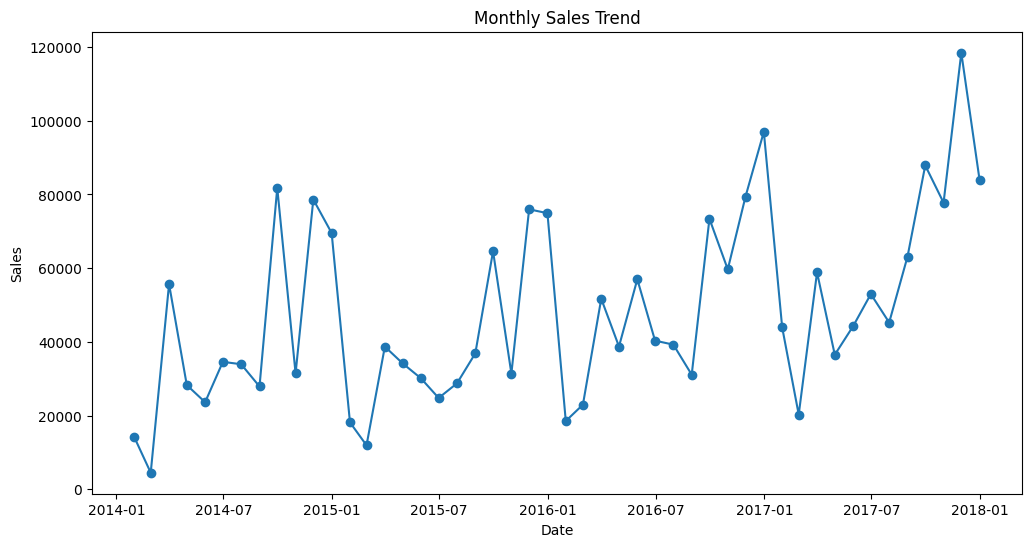

In [7]:
# ==========================
# VISUALIZATION 1
# Sales Trend Graph
# ==========================

plt.figure(figsize=(12,6))

plt.plot(monthly_sales['Order Date'],
         monthly_sales['Sales'],
         marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()


In [8]:
# ==========================
# TRAIN TEST SPLIT
# ==========================

train = monthly_sales.iloc[:36]

test = monthly_sales.iloc[36:]

X_train = train[['time_index']]

y_train = train['Sales']

X_test = test[['time_index']]

y_test = test['Sales']



In [9]:
# ==========================
# MODEL BUILDING
# ==========================

model = LinearRegression()

model.fit(X_train,y_train)

# Predictions
predictions = model.predict(X_test)



In [10]:
# ==========================
# MODEL EVALUATION
# ==========================

MAE = mean_absolute_error(y_test,predictions)

RMSE = np.sqrt(mean_squared_error(y_test,predictions))

print("MAE:",MAE)

print("RMSE:",RMSE)



MAE: 19663.551638810957
RMSE: 23664.502793599087


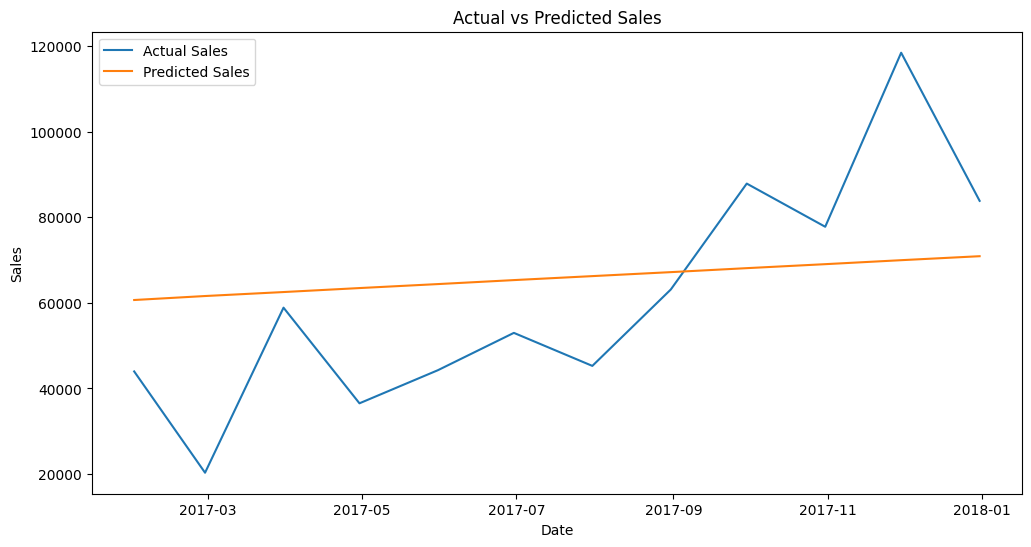

In [11]:
# ==========================
# VISUALIZATION 2
# Actual vs Predicted
# ==========================

plt.figure(figsize=(12,6))

plt.plot(test['Order Date'],
         y_test,
         label="Actual Sales")

plt.plot(test['Order Date'],
         predictions,
         label="Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()


In [12]:

# ==========================
# FUTURE FORECAST
# ==========================

future_periods = 12

future_index = np.arange(
    len(monthly_sales),
    len(monthly_sales)+future_periods
)

future_predictions = model.predict(
    future_index.reshape(-1,1)
)

future_dates = pd.date_range(
    monthly_sales['Order Date'].max(),
    periods=future_periods+1,
    freq='M'
)[1:]

future_df = pd.DataFrame()

future_df['Date'] = future_dates

future_df['Forecast Sales'] = future_predictions

print(future_df)



         Date  Forecast Sales
0  2018-01-31    71828.230288
1  2018-02-28    72758.859327
2  2018-03-31    73689.488366
3  2018-04-30    74620.117406
4  2018-05-31    75550.746445
5  2018-06-30    76481.375485
6  2018-07-31    77412.004524
7  2018-08-31    78342.633563
8  2018-09-30    79273.262603
9  2018-10-31    80203.891642
10 2018-11-30    81134.520682
11 2018-12-31    82065.149721


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_6694/3009886395.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


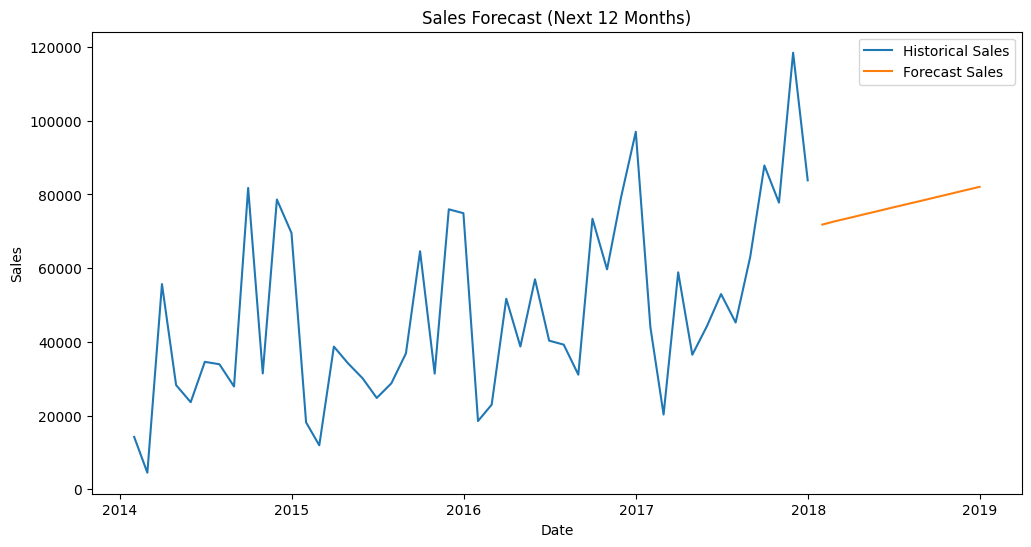

In [13]:
# ==========================
# VISUALIZATION 3
# Forecast Graph
# ==========================

plt.figure(figsize=(12,6))

plt.plot(monthly_sales['Order Date'],
         monthly_sales['Sales'],
         label="Historical Sales")

plt.plot(future_dates,
         future_predictions,
         label="Forecast Sales")

plt.title("Sales Forecast (Next 12 Months)")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()



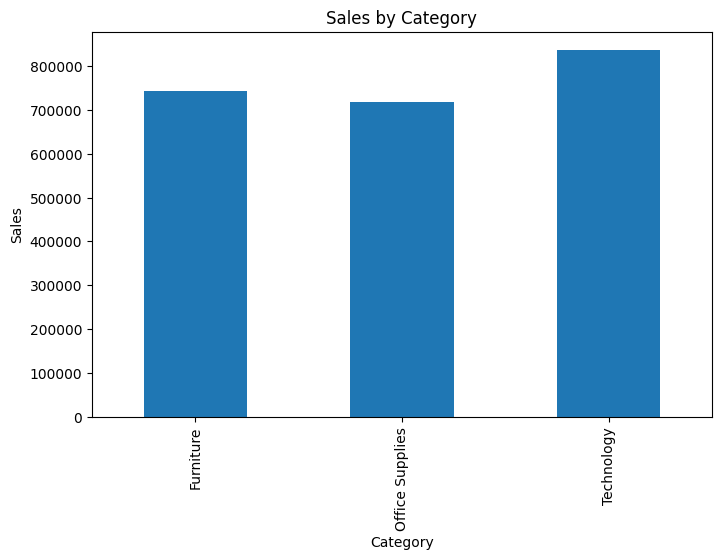

In [14]:
# ==========================
# VISUALIZATION 4
# Category Sales Graph
# ==========================

category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()


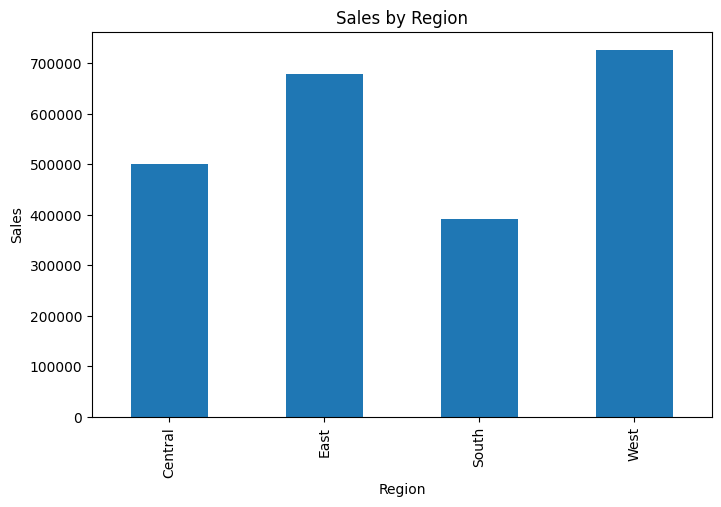

PROJECT COMPLETED


In [15]:
# ==========================
# VISUALIZATION 5
# Region Sales Graph
# ==========================

region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

print("PROJECT COMPLETED")